# 심층 신경망 훈련 

### 깊은 신경망을 훈련하기 위한 문제 
- 출력층에서 멀어질수록 그레디언트가 커지거나 작아지는 문제 
- 대규모 신경망을 위한 훈련 데이터가 충분하지 않거나 레이블 작업 비용이 너무 많이듦
- 훈련이 극단적으로 느려짐 
- 수 많은 파라미터를 가진 모델은 과대적합의 위험이 있음

### 해결방법 
- 전이 학습 
- 비지도 사전 훈련 
- 최적화 
- 대규모 신경망을 위한 규제 기법

# 1. 그레디언트 소실/폭주 문제 

## 정의 
- 그레디언트 소실: 역전파 과정에서 가중치 업데이트에 사용되는 그레디언트가 너무 작아져서 학습이 제대로 이루어지지 않는 현상
- 그레디언트 폭주: 그레디언트가 너무 커져서 가중치 업데이트가 불안정해지는 현상
  - 주로 순환 신경망에서 발생 

## 원인 
- `로지스틱 시그모이드 활성화 함수`와 `가중치 초기화 방식`의 조합 
  - 출력의 분산이 입력의 분산보다 더 큼
  - 신경망의 위쪽으로 갈 수록 층을 지날 때마다 분산이 계속 커짐 
  - 가장 높은 층에서는 활성화 함수가 0이나 1로 수렴 
  
### 시그모이드 함수의 문제 
- 시그모이드 함수의 평균 : 0.5 
- 입력이 커지면 출력이 0이나 1로 수렴
- 역전파 할 그레디언트가 없음 -> 아래층에는 아무것도 전달되지 않음

- 그래프를 그리기 위한 matplotlib 작성

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
import sys
import warnings
# UserWarning 카테고리의 모든 경고를 무시
warnings.filterwarnings("ignore", category=UserWarning)

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

- 시그모이드 활성화 함수의 수렴

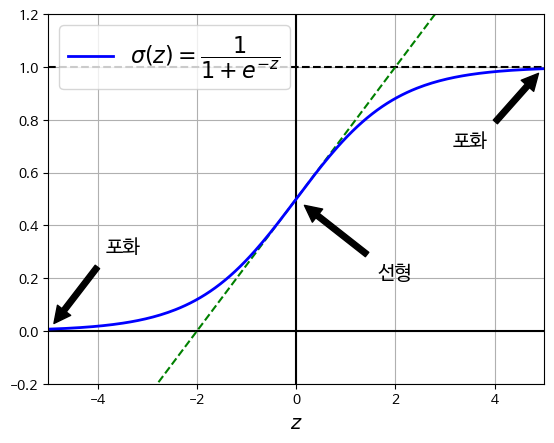

In [3]:
# 추가 코드 - 이 셀은 그림 11-1을 생성하고 저장합니다.

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('포화', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('포화', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('선형', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

plt.show()

----

## 글로럿과 He 초기화
### 가정
- 각 층의 출력에 대한 분산이 입력에 대한 분산과 같아야 역전파 시 양방향 신호가 적절하게 흐른다고 가정
- 역방향에서 층을 통과하기 위해 전과 후 그레디언트 분산이 동일해야함
- `팬 인`(층 입력 갯수)과 `팬 아웃`(출력 연결 갯수)가 같지 않으면 위 가정들을 보장 할 수 없음

### 글로럿 초기화
- 연결 가중치를 `랜덤`하게 초기화

#### 글로럿 초기화 공식
- 가정 : 시그모이드 활성화 함수 사용
- $fan_{\textrm{avg}}=(fan_{\textrm{in}}+fan_{\textrm{out}})/2$
- 아래와 같은 정규분포에서 랜덤하게 초기화 
  - 평균 = 0 
  - 분산 = $\sigma^2 = \frac{1}{fan_{\textrm{avg}}}$ 
- 혹은 아래와 같은 균등 분포에서 초기화 
  - $-r$ 과 $r$  사이 균등 분포 
  - 이때, $r=\sqrt{\frac{3}{fan_{\textrm{avg}}}}$

### 르쿤 초기화 
- 글로럿 초기화에서 $fan_{\textrm{avg}}$을 $fan_{\textrm{in}}$ 으로 변경 
  - $fan_{\textrm{in}} = fan_{\textrm{out}} $ 이면, `글로럿 초기화 = 르쿤 초기화`

### He 초기화 (카이밍 초기화)
- `ReLU`  활성화 함수와 이를 위한 초기화 전략을 사용 

|초기화 전략|활성화 전략|정규분포|
|---|---|---|
|글로럿|활성화 함수 없음, tanh, 로지스틱, 소프트맥스| $1/fan_{\textrm{avg}}$|
|르쿤|SELU| $1/fan_{\textrm{in}}$|
|He|ReLU, LeakyReLU, ELU, GELU,Swish,  Mish| $2/fan_{\textrm{in}}$|

### 케라스를 통한 초기화
- `kernel_initializer='he_uniform'` OR `he_normal`로 하면 He 초기화 사용 가능 
- `VarianceScaling` : 다른 초기화 방법 사용

In [4]:
import tensorflow as tf 

### He 초기화 
dense =tf.keras.layers.Dense(50, activation='relu',kernel_initializer="he_normal")

### 초기화 방식 변경 : fan_out 기반 He 초기화 
he_avg_init = tf.keras.initializers.VarianceScaling(
    scale=2.0, mode='fan_out', distribution='uniform')

dense = tf.keras.layers.Dense(50,activation="sigmoid",kernel_initializer=he_avg_init)

## 고급 활성화 함수
- 활성화 함수를 잘못 선택하면 그레이디언트 소실이나 폭주로 이어질 수 있음
- 기존에는 시그모이드, ReLU 등이 사용되었으나 이 것도 완벽하지 않음 

### 죽은 ReLU 문제 
- 일부 뉴런이 0 이외의 값을 출력하지 않음 
- 학습률이 클 수록 뉴런이 죽어 있는 비율이 커짐 


### Leaky ReLU
#### 정의 
$\textrm{LeakyReLU}_a(z) =  \textrm{max} (\alpha \cdot z, z)$

#### 새는 정도
- $\alpha$ : 함수가 `새는` 정도 
- `새는 정도` : $z < 0$ 일 때 함수의 기울기 
- $z < 0$일 때 기울기가 절대 죽지 않게 만듦 
- 다시 깨어날 가능성을 얻음 
- $\alpha=0.2$ 가 $\alpha=0.01$보다 더 나은 성능을 보임

#### 단점 
- 소규모 데이터셋에서는 훈련세트에 과대 적합이 될 위험이 있음 


- LeakReLU 그래프 

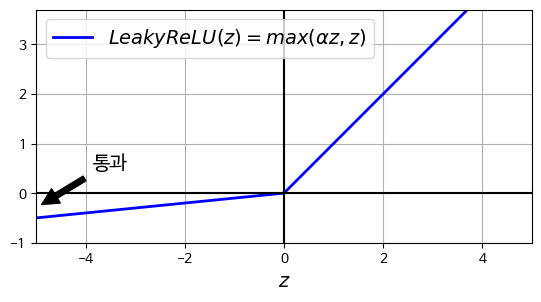

In [5]:
def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('통과', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

-  케라스를 통한 LeajyReLU 구현
- He 초기화 사용 

In [6]:
### leaky ReLU 레이어 생성
leaky_relu=tf.keras.layers.LeakyReLU(alpha=0.2)

### 층 생성 
dense = tf.keras.layers.Dense(50, activation=leaky_relu,kernel_initializer="he_normal")

### 별도 층으로 모델 추가 
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # 활성화 함수 없음
    tf.keras.layers.LeakyReLU(alpha=0.2),  # 별도의 층으로 활성화 함수 추가
])

## ELU와 SELU
### leaky ReLU , PReLu의 단점 
- `매끄러운 함수`가 아님 
    - `매끄러운 함수` 가 아님: 도함수가 $z=0$ 일 때, 갑자기 바뀜 
    - 불연속성이 있음 -> 경사하강법의 최적점을 진동하게 만들거나 수렴을 느리게 만듦 
    - `부드로운` 변형이 필요함 
    
    
### ELU
#### 정의 
$\textrm{ELU}_\alpha(z) = \begin{cases} z & \text{if } z \geq 0 \\ \alpha (\textrm{exp(z)} - 1) & \text{if } z < 0 \end{cases}$

#### ReLU와의 차이점 
- $z<0$ 일 때, 음수값 -> 활성함수의 평균 출력이 0에 가까워짐 -> 그레디언트 소실 문제 완화 
- 하이퍼파라미터 $\alpha$눈 $z$가 큰 음숫값 일 때, ELU가 수렴 할 값의 역수를 정의 
- $z<0$ 이어도 그레디언트가 0 아님 -> 죽은 뉴런을 만들지 않음 
- $\alpha=1$ 이면 $z=0$에서 급격히 변동 하지 않음 -> 모든 구간에서 매끄러워 경사하강법의 속도를 높임 

#### 단점 
- 지수 함수를 사용하기 때문에 계산이 느림 

#### keras에서 ELU 사용 
- `activation="elu"` 

In [7]:
dense = tf.keras.layers.Dense(50, activation="elu",
                              kernel_initializer="he_normal")

### SELU
#### 정의 
- 스케일이 조정됨 ELU 활성화 함수의 변형 
- SELU를 사용하면 네트워크가 `자기정규화`됨 ->훈련하는 동안 각 층의 출력이 평균0과 표준편차1을 유지하려는 경향을 보임 

#### 사용 조건 
- 입력 특성은 평균 0, 표준편차 1로 정규화되어야 함
- 모든 은닉층의 가중치는 `lecun_normal` 초기화로 초기화되어야 함
- 자기 정규화는 MLP에서만 보장됨 
-  규제 사용 불가 : $ \ell_1,\ell_2$ 규제, 맥스-노름, 배치 정규화, 드롭아웃

#### 장점
- MLP(매우 깊은 네트워크)에서 높은 성능을 보임 

#### 단점
- 순환 신경망이나 스킵 연결 구조에서는 자기 정규화를 보장하지 못함 -> 성능이 ELU보다 낮을 수 있음 

In [8]:
dense = tf.keras.layers.Dense(50, activation="selu",
                              kernel_initializer="lecun_normal")

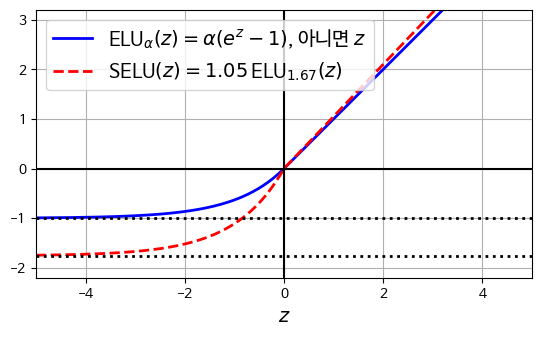

In [9]:
from scipy.special import erfc

# 평균 0, 표준 편차 1로 자체 정규화하기 위한 alpha 및 sacle
# (논문에 있는 식 14 참조):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$, 아니면 $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

----

## GELU, Swish, Mish 

### GELU
#### 정의 
$\textrm{GELU}(z) = z\cdot\Phi(z)$
- $\Phi(z)$ : 표준 가우스 누적 분포 함수 
  - 평균 0,  표준분포 1인 정규 분포에서 랜덤하게 샘플링한 값이 $z$보다 작거나 같은 확률

- ReLU 활성화 함수의 부드러운 변형
- 다른 함수와 다르게 볼록한 단조 함수가 아님

#### 장점 
- 경사 하강법이 복잡한 작업에서 잘 작동함 

#### 단점 
- 계산량이 더 많으며 성능 향상이 추가 비용이 많아짐

#### 케라스에서 사용 
`activation="gelu"`

### Swish
#### 정의
- SiLU 함수의 변형
 - SiLU : $z\sigma(z)$
- Swish : $\textrm{Swish}_\beta(z) = z \cdot \sigma(\beta z)$

#### 하이퍼 파라미터 $\beta$
- 훈련 가능한 파라미터로 만들고, 경사하강법으로 최적화 가능 
- 튜닝 가능 

#### 단점 
- 데이터에 대한 과대 적합의 위험 존재 

#### 케라스에서 사용 
`activation="swish"`

### Mish
#### 정의
- Swish의 변형
- $\textrm{Mish}(z) = z \cdot \tanh(\textrm{softplus}(z))$
- $\textrm{softplus}(z) = \log(1 + \text{exp(z)})$

#### 장점
- 매끄러움 
- 볼록하지 않고 단조함수가 아님
- $z$가 음수 일 때, Swish와 동일
- $z$가 양수 일 때, GELU와 동일 

#### 케라스에서 사용 
- keras에서 지원하고 있지 않음 
- 사용자 정의 활성화 함수로 구현 가능

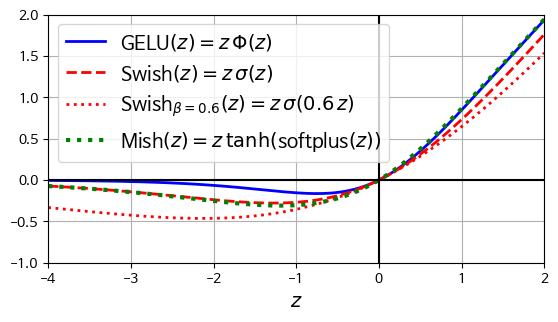

In [10]:
def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

plt.show()

## 배치 정규화 
### 원리
> 입력을 정규화 한 다음 스케일을 조정하고 이동시킴 

- 각 층에서 활성화 함수를 통과하기 전이나 후에 모델에 연산 추가 
    - 연산 : 입력을 원점에 맞추고 정규화 후 두 개의 새로운 파라미터로 결과 값의 스케일을 조정하고 이동 
    - 파라미터 : 스케일 조정 파라미터, 이동 파라미터
- 배치 정규화를 추가하면, 훈련세트를 표준화 할 필요가 없어짐 

#### 평균과 표준 편차 추정
- 정규화 하려면 평균과 표준 편차 추정 필요 
- 미니 배치에서 입력의 평균과 표준 편차를 계산

##### 평균 $\mu_B$
$\mu_B = \frac{1}{m_B} \sum_{i=1}^{m_B} \mathbf{x}^{(i)}$
- 미니배치 B에 대해서 평가한 입력 평균 벡터 
- $m_B$ : 미니배치 B의 크기(샘플 수)

##### 표준 편차 $\sigma_B^2$
$\sigma_B^2 = \frac{1}{m_B} \sum_{i=1}^{m_B} (\mathbf{x}^{(i)} - \mu_B)^2$
- \sigma_B^2 : 미니배치 B에 대해서 평가한 입력의 분산
- $\sigma_B$ : 미니 배치 B의 표준 편차

$\hat{\mathbf{x}}^{(i)} = \frac{\mathbf{x}^{(i)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$
- $\hat{\mathbf{x}}^{(i)}$ : 평균이 0, 정규화된 샘플 i의 입력 
- $\epsilon$ : 안전을 위한 항
  - 분모가 0이 되는 것 방지 
  - 그레디언트가 너무 커지는 것을 방지
  - 매우 작은 수 (예: $10^{-5}$)로 설정
$z^{(i)} = \gamma \otimes \hat{\mathbf{x}}^{(i)} + \beta$
- $\gamma$ : 출력 스케일 조정 파라미터
- $\otimes$ : 원소별 곱셈
- $\beta$ : 출력 이동 파라미터 (오프셋 파라미터)
- $z^{(i)}$ : 배치 정규화 연산의 출력 
  - 스케일 조정 및 이동 시킨 결과물 
  
  

### 배치 정규화의 예측 
- 훈련이 끝난 후 전체 훈련 세트를 신경망에 통과시켜 배치정규화 층의 각 입력에 대한 평균과 표준 편차 계산 
-> 대부분 배치 정규화 구녛ㄴ은 층의 입력 평균과 표준 편차의 이동평균을 사용해 최종 통계를 추정 
->  `BatchNormalization` 층으로 사용 가능 


### 장점 
- 모든 심층 신경망에서 성능을 크게 향상 시킴 
- 이미지넷 분류 작업에서 큰 성과를 보임 
- 수렴성을 가진 활성화 함수 (tanh, 시그모이드 등) 사용 가능 
- 가중치 초기화에 네트워크가 훨씬 덜 민감
- 규제와 같은 경할 -> 다른 규제 필요성을 줄임 


### 단점 
- 모델의 복잡도를 상승 시킴
- 실행 시간이 오래 걸림 

### 케라스 구현 배치 정규화 
- 은닉층과 활성화 함수 이전/이후 `BatchNormalization` 레이어 추가
    - 모델의 첫번째 층으로 배치 정규화 층을 추가해 정규화를 수행 가능 

- 배치 정규화 층은 입력 마다 `파라미터 4개` ($\gamma,\beta,\mu,\sigma$) 추가
  - $\mu,\sigma$ : 이동 평균 
    - 역잔파로 학습되지 않음 -> `Non-trainable` 파라미터 

In [11]:
# 이름 카운터를 지우고 랜덤 시드를 설정합니다.
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model =tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    
    ### 배치 정규화 층 추가 (은닉층 - 활성화 함수 이전에 추가)
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(300, activation="relu", kernel_initializer="he_normal"),
    ### 배치 정규화 층 추가 (은닉층 - 활성화 함수 이전에 추가)
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    ### 배치 정규화 층 추가 (은닉층 - 활성화 함수 이전에 추가)
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

- 첫번째 `배치 정규화 층`의 파라미터 확인 
  - $\gamma, \beta$ : 학습 가능한 파라미터
  - $\mu, \sigma$ : 이동 평균 (Non-trainable 파라미터)

In [12]:
print("첫번째 층 레이어 : ", model.layers[1])
[(var.name, var.trainable) for var in model.layers[1].variables]

첫번째 층 레이어 :  <BatchNormalization name=batch_normalization, built=True>


[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

- 모델 훈련 데이터 생성 (fashion Mnist)

In [13]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

- 모델 컴파일

In [14]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7570 - loss: 0.7109 - val_accuracy: 0.8506 - val_loss: 0.4004
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8558 - loss: 0.4066 - val_accuracy: 0.8672 - val_loss: 0.3674


- 배치 정규화층을 활성화 함수 이후보다 이전에 추가하는 것이 나은지는 논의가 분분 
- 배치 정규화층 입력마다 이동 파라미터를 포함 -> 이전 층의 편향을 뺄 수 있음 -> `use_bias=False`
- 첫번째 은닉층이 배치 정규화 층 두개 사이에 끼지 않도록 첫 번째 배치 정규화층을 사용 할 수 있음 

In [15]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    ### 첫번째 배치 정규화 제거 
    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False), ### use_bias=False -> 이전층 편향 제거 
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False), ### use_bias=False -> 이전층 편향 제거 
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7279 - loss: 0.8240 - val_accuracy: 0.8408 - val_loss: 0.4283
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8470 - loss: 0.4409 - val_accuracy: 0.8618 - val_loss: 0.3761


### 하이퍼 파라미터 튜닝 
- BatchNormalization은 조정할 하이퍼 파라미터가 없음 
- `momentum(모멘텀)` : 이동 평균을 계산할 때 사용되는 하이퍼 파라미터
  - 새로운 값 $\textrm{v}$에 대하여 아래와 같은 이동 평균 
  - $\hat{v} \gets \hat{v} \times \textrm{momentum} + \textrm{v} \times \textrm{1-momentum}$
  - 적절한 모멘텀 값은 1에 가까움 
- `axis` : 정규화 할 축 걸정 
  - 기본 값 : -1 (마지막 축 정규화)

## 그레디언트 클리핑
> 역전파 될 때 특정 임계값을 넘어서지 못하게 그레디언트를 잘라내는 것

### 케라스 구현 
- 옵티마이저를 만들 때, `clipvalue`와 `clipnorm` 매개 변수 지정 
- 그레디언트 벡터의 모든 원소를 `-1.0 ~ 1.0` 사이로 제한
  - 손실의 모든 편미분 값을 `-1.0 ~ 1.0` 사이로 제한
- `clipvalue` : 그레디언트 벡터의 모든 원소를 지정된 값으로 제한
- `clipnorm` : 그레디언트 벡터의 방향을 바꾸지 않고 크기만 제한 

In [16]:
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

-----

# 2. 사전 훈련된 층 재사용

## 전이 학습 
> 이미 학습된 모델을 다른 모델에 적용하는 학습 방법 
- 훈련속도 상승 및 필요 훈련 데이터 감소 

### 층 재사용 
#### 변경이 필요한 층
- `출력층` : 변경 필요 
    - 새로운 작업에 유용하지 않거나 출력 갯수가 상이 
  - `은닉층` : 하위 은닉층이 좀 더 `유용`함 
    - 고수준 특성은 원본 작업에서 유용했던 특성과 다를 수 있음 
#### 층 재사용 방법
-  재사용 할 층 동결 
-  모델 훈련 후 성능 평가 
-  맨 위의 은닉층의 동결 해제
-  역전파를 통한 가중치 조정 
   -  해제 하면서 학습률을 감소 
-  훈련데이터가 적고 성능이 안 좋은 경우 재사용 할 적절한 은닉층 개수를 찾을 때까지 반복 혹은 추가 

----

## 케라스를 사용한 전이 학습 

### 패션 MNIST 데이터셋을 사용한 전이 학습
- 모델 A : 샌들과 셔츠를 제외한 클래스로 학습한 모델 
-> 샌들과 셔츠 분류를 위한 이진 분류 모델 B를 생성 
  - 양성 클래스 : 샌들
  - 음성 클래스 : 셔츠 
- 샌들과 셔츠 데이터만 사용하는 경우 -> 데이터의 수가 적음 
- 모델 A를 이용하여 전이학습 수행 

#### 모델 A 생성 
- 정확도 91.115%

In [17]:
pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # A에 대한 클래스 ID 재정의
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

tf.random.set_seed(42)

model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model_A.save("my_model_A.h5")

Epoch 1/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5137 - loss: 1.5943 - val_accuracy: 0.7912 - val_loss: 0.7204
Epoch 2/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8036 - loss: 0.6567 - val_accuracy: 0.8406 - val_loss: 0.5205
Epoch 3/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8447 - loss: 0.5038 - val_accuracy: 0.8581 - val_loss: 0.4420
Epoch 4/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8642 - loss: 0.4338 - val_accuracy: 0.8716 - val_loss: 0.3981
Epoch 5/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8745 - loss: 0.3922 - val_accuracy: 0.8774 - val_loss: 0.3709
Epoch 6/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8812 - loss: 0.3649 - val_accuracy: 0.8807 - val_loss: 0.3523
Epoch 7/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8861 - loss: 0.3451 - val_accuracy: 0.8837 - val_loss: 0.3386
Epoch 8/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8893 - loss: 0.3301 - 

#### 전이 학습을 사용하지 않는 경우의 모델 B

In [18]:
tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7135 - loss: 0.6483 - val_accuracy: 0.7893 - val_loss: 0.6310
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7590 - loss: 0.6296 - val_accuracy: 0.8210 - val_loss: 0.6137
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8300 - loss: 0.6126 - val_accuracy: 0.8427 - val_loss: 0.5981
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8518 - loss: 0.5966 - val_accuracy: 0.8566 - val_loss: 0.5835
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8662 - loss: 0.5812 - val_accuracy: 0.8665 - val_loss: 0.5699
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8781 - loss: 0.5669 - val_accuracy: 0.8704 - val_loss: 0.5570
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8850 - loss: 0.5537 - val_accuracy: 0.8843 - val_loss: 0.5448
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9035 - loss: 0.5413 - val_accuracy: 0.8952 - val_loss: 0.5331


[0.4262821674346924, 0.9290000200271606]

#### 모델 A를 이용한 모델 B 생성
- 마지막 레이어 (출력층) 제거

In [19]:
model_A =tf.keras.models.load_model("my_model_A.h5")

### 마지막 레이어 제거 (출력층)
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])  
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

tf.random.set_seed(42)

- model_B 와 model_B_on_A 는 층을 공유 
  - model_B_on_A 학습 시, model_B의 가중치가 업데이트됨
  - clone 을 통해 복제 후 학습해야 영향 받지 않고 진행 가능 

In [20]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

#### 가중치 학습 동결
- 새로운 출력 층이 랜덤하게 초기화 
- 첫 에포크 동안 큰 오차 발생 
- 큰 오차 그레디언트가 재사용된 가중치를 망칠 가능성 있음
- 몇 에포크 동안 재사용 층 `동결` (가중치를 학습 할 시간을 부여)

- `trainsible=False`로 설정하여 동결

In [21]:
### 마지막 층(출력층)을 제외한 모든 층을 동결
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False 
    
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=optimizer,
                     metrics=["accuracy"])

#### 가중치 동결 해제 
- 재사용층 동결 해제 및 다시 컴파일 
- 재사용된 층 튜닝 후 훈련 지속 
    - 학습률을 낮추는 것이 좋음 (가중치가 망가지는 것 방지)

In [22]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=20,
                          validation_data=(X_valid_B, y_valid_B))

### 가중치 학습 동결 해제
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True
    
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                            validation_data=(X_valid_B, y_valid_B))

### 확인 
model_B_on_A.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5745 - loss: 0.8530 - val_accuracy: 0.6281 - val_loss: 0.5886
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7053 - loss: 0.5256 - val_accuracy: 0.7784 - val_loss: 0.5122
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8235 - loss: 0.4877 - val_accuracy: 0.8111 - val_loss: 0.5029
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8210 - loss: 0.4849 - val_accuracy: 0.8200 - val_loss: 0.4982
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8468 - loss: 0.4814 - val_accuracy: 0.8229 - val_loss: 0.4934
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8468 - loss: 0.4765 - val_accuracy: 0.8239 - val_loss: 0.4884
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8505 - loss: 0.4712 - val_accuracy: 0.8289 - val_loss: 0.4834
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8517 - loss: 0.4658 - val_accuracy: 0.8348 - val_loss: 0.4785


[0.2669573128223419, 0.9265000224113464]

- 정확도 상승 : 91.115% -> 93.3%
- 하지만 `속임수`가 존재함 
  -  좋은 결과가 나올 때 까지 설정을 계속 바꿈 
  -  전이 학습은 작은 완전 연결 네트워크에서 잘 작동하지 않음 
  -  전이 학습은 조금 더 일반적인 특성을 감지하는 경향 -> 심층 합성곱 신경망에서 잘 작동함 

----

## 비지도 사전 훈련
- `오토 인코더` 혹은 `생성적 적대 신경망(GAN)`을 사용하여 비지도 사전 훈련 진행 
- 오토인코더나 GAN 판별자의 하위 층을 재사용 -> 새로운 작업에 맞는 출력 층 추가 
- 지도학습으로 최종 네트워크 튜닝 
  
### 탐욕적 층 단위 사전 훈련 기법 
- 딥러닝 초기 훈련 기법 
- RBM 사용 -> 층 동결 -> 다른 층 추가 -> 모델 다시 훈련 -> 새로운 층 동결 -> 다른층 추가 -> 모델 다시 훈련 


## 보조 작업에서 사전 훈련 

- 레이블된 훈련데이터를 쉽게 얻거나 생성할 수 있는 `보조 작업`에서 첫 번째 신경망을 훈련 
- 하위 층을 실제 작업을 위해 재사용
- 첫번째 신경망의 하위층은 두번째 신경망에 재사용 될 수 있는 특성 추출기를 학습 

-----

# 3. 고급 옵티마이저

- 큰 심층 신경망은 훈련 속도가 심각하게 저하됨
- 훈련 속도를 높이는 방법 
  - 연결 가중치에 좋은 초기화 전략 사용 
  - 좋은 활성화 함수 사용 
  - 배치 정규화 사용
  - 사전 훈련된 네트워크 일부 재사용 
  - 고속 옵티마이저 사용

- 패션 MNIST에서 옵티마이저를 테스트하는 간단한 함수

In [23]:
def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

## 모멘텀 최적화 
> 경사하강법에 관성(momentum)을 추가하여 최적화 속도를 높이는 방법

### 모멘텀
- `모멘텀` : 관성 
  - 움직이는 물체가 같은 방향으로 움직이려는 경향 
  - 머신러닝에서의 `모멘텀` : 과거 그레디언트가 이동했던 방향과 크기로 현재 업데이트를 반영

### 알고리즘 

#### 경사하강법 가중치 업데이트 
$\theta\leftarrow \theta-\eta\cdot\nabla_{\theta} J(\theta)$
- 가중치에서 학습률을 곱한 그레디언트 만큼 감소 
  - $\theta$ : 가중치 
  - $J(\theta)$ : 가중치에 대한 비용함수 
  - $(\nabla_{\theta} J(\theta))$ : $J(\theta)$의 그레디언트  
  - $\eta$ : 학습률 
- 단점 : 이전 그레디언트 고려 X 
  - 그레디언트가 작아질수록 훈련 속도가 낮아짐 

#### 모멘텀 알고리즘 
- `모멘텀 최적화` : 이전 그레디언트가 얼마 였는지 중요함 
- 가중치 업데이트 : 
- 가중치 + 모멘텀 벡터 갱신
- $\theta \leftarrow \theta + \textrm{m}$
  - $\textrm{m}$ : 모멘텀 벡터 
- 모멘텀 벡터 $\textrm{m}$ 구하는 법 
  - $\textrm{m}\leftarrow \beta \cdot\textrm{m}-\eta\cdot\nabla_{\theta} J(\theta)$
    - $\beta$ : 마찰 하이퍼파라미터 
      - 0 (높은 마찰) ~ 1 (낮은 마찰)
      - 일반적인 값 : 0.9
    - 그레디언트가 일정하다면 $\eta \cdot\frac{1}{1-\beta}$와 같음 

#### 장점 
- 최적점도달 시 빠르게 내려가게 만듦
- 지역 최적점을 건너뛰는데 도움을 줌 

### 케라스에서 모멘텀 최적화 구현
- `momentum`  매개변수 지정
- 일반적인 경사하강법보다는 성능이 항상 좋음

In [24]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

- 모델 빌드 및 훈련

In [25]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
history_sgd = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6637 - loss: 0.9889 - val_accuracy: 0.8250 - val_loss: 0.5092
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8279 - loss: 0.4904 - val_accuracy: 0.8368 - val_loss: 0.4565
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8483 - loss: 0.4354 - val_accuracy: 0.8466 - val_loss: 0.4255
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8592 - loss: 0.4033 - val_accuracy: 0.8538 - val_loss: 0.4006
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8659 - loss: 0.3811 - val_accuracy: 0.8576 - val_loss: 0.3864
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8713 - loss: 0.3638 - val_accuracy: 0.8614 - val_loss: 0.3793
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8756 - loss: 0.3498 - val_accuracy: 0.8634 - val_loss: 0.3753
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8801 - loss: 0.3381 - 

In [26]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
history_momentum = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6752 - loss: 0.9826 - val_accuracy: 0.8176 - val_loss: 0.4989
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8332 - loss: 0.4788 - val_accuracy: 0.8368 - val_loss: 0.4478
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8491 - loss: 0.4316 - val_accuracy: 0.8448 - val_loss: 0.4178
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8594 - loss: 0.4032 - val_accuracy: 0.8522 - val_loss: 0.3983
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8673 - loss: 0.3814 - val_accuracy: 0.8552 - val_loss: 0.3858
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8722 - loss: 0.3641 - val_accuracy: 0.8578 - val_loss: 0.3782
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8769 - loss: 0.3500 - val_accuracy: 0.8620 - val_loss: 0.3686
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8804 - loss: 0.3374 - 

## 네스테로프 가속 경사(NAG)
- 모멘텀의 방향으로 조금 앞선 $(\theta+\beta\textrm{m})$ 비용함수 그레디언트 계산
- $\theta \leftarrow \theta + \textrm{m}$
  - $\textrm{m}$ : 모멘텀 벡터 
- 모멘텀 벡터 $\textrm{m}$ 구하는 법 
  - $\textrm{m}\leftarrow \beta \cdot\textrm{m}-\eta\cdot\nabla_{\theta} J(\theta+\beta\textrm{m})$

### 특징 
- 일반적으로 모멘텀 벡터는 `최적점을 향하는 방향`을 가리킴 -> 약간 더 정확한 방향을 가르킴
- 일반적으로는 NAG가 최적값에 더 가까움 
  - NAG가 모멘텀 최적화 보다 확연히 빠름 
  - 진동을 감소시키고 수렴을 빠르게 만들어줌 

### 케라스에서 구현 
- `use_nesterov=True`로 구현


In [33]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
history_nesterov = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6669 - loss: 0.9882 - val_accuracy: 0.8228 - val_loss: 0.4905
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8358 - loss: 0.4760 - val_accuracy: 0.8378 - val_loss: 0.4471
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8523 - loss: 0.4274 - val_accuracy: 0.8448 - val_loss: 0.4286
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8620 - loss: 0.3992 - val_accuracy: 0.8466 - val_loss: 0.4130
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8686 - loss: 0.3786 - val_accuracy: 0.8516 - val_loss: 0.4037
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8729 - loss: 0.3620 - val_accuracy: 0.8536 - val_loss: 0.3952
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8768 - loss: 0.3482 - val_accuracy: 0.8556 - val_loss: 0.3889
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8800 - loss: 0.3367 - 

## AdaGrad
> AdaGrad 알고리즘은 가장 가파른 차원을 따라 그레디언트 벡터 스케일을 감소
- 경사하강법은 가장 가파른 경사를 따라 내려가기 시작 골짜기 아래에서 느리게 이동
- 알고리즘은 이를 일찍 감지 -> 전역 최적점 쪽으로 정확한 방향으로 이끔
### AdaGrad의 알고리즘
#### $s$ 벡터에 그레디언트 제곱 누적
$s \leftarrow s + \nabla_{\theta}J(\theta) \otimes \nabla_{\theta}J(\theta)$

- $\otimes$ : 원소별 곱셈
- s벡터의 각 원소마다 파라미터 $\theta$에 대한 비용 함수의 편미분을 제곱하여 누적
- 벡터 s의 각 원소 마다 s에 $s + (\partial{J(\theta)/\partial(\theta)})^2$ 한 것
   - 비용함수의 i번째 차원을 따르는게 빠르다면 s는 반복을 할 때마다 커짐
#### 스케일 조정
$\theta \leftarrow \theta -\eta \nabla_{\theta}J(\theta) \oslash \sqrt{s+\varepsilon}$
- 경사하강법과 유사
   - 차이점 : $\sqrt{s+\varepsilon}$를 나누어 스케일 조정
   - $\oslash$ : 원소별 나눗셈
#### 적응적 학습률
- AdaGrad 알고리즘은 학습률을 감소 시키면서 경사가 완만한 차원보다 가파른 차원에 대해 더 빠르게 감소
- 학습률이 상황에 따라 다르게 적용됨

### 장점
- 전역 최적점 방향으로 곧장 가서 갱신에 도움됨
- 학습률 하이퍼파라미터 $\eta$ 를 덜 튜닝해도 되는 장점이 있음
- 간단한 2차 방정식 문제에 대해서는 잘 작동함 
### 단점 
- 신경망 훈련 시, 너무 일찍 멈추는 경우가 있음 
   - 학습률이 너무 감소하여 전역 최적점에 도착하 전에 알고리즘을 멈춤 
   - 케라스의 `Adagrad` 옵티마이저가 있지만 심층 신경망에서 사용하면 안됨 

In [28]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)
history_adagrad = build_and_train_model(optimizer) 

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5310 - loss: 1.5018 - val_accuracy: 0.7790 - val_loss: 0.6996
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7816 - loss: 0.6742 - val_accuracy: 0.8036 - val_loss: 0.5949
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8087 - loss: 0.5873 - val_accuracy: 0.8162 - val_loss: 0.5485
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8192 - loss: 0.5447 - val_accuracy: 0.8240 - val_loss: 0.5214
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8265 - loss: 0.5178 - val_accuracy: 0.8304 - val_loss: 0.5028
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8314 - loss: 0.4991 - val_accuracy: 0.8324 - val_loss: 0.4893
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8360 - loss: 0.4850 - val_accuracy: 0.8338 - val_loss: 0.4787
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8391 - loss: 0.4738 - 

---
## RMSProp
> 가장 최근 반복에서 비롯된 그레디언트만 누적하는 방식

- 기존 방식은 처음부터 끝까지 모든 그레디언트를 누적시킴 

### RMSProp 알고리즘 
#### $s$ 벡터에 그레디언트 제곱 누적
$s \leftarrow \rho \cdot s + (1-\rho)\cdot\nabla_{\theta}J(\theta) \otimes \nabla_{\theta}J(\theta)$
- $\rho$ : 감쇠율 
   - 일반적인 감쇠율 : 0.9
#### 스케일 조정
$\theta \leftarrow \theta -\eta \nabla_{\theta}J(\theta) \oslash \sqrt{s+\varepsilon}$
-  $\sqrt{s+\varepsilon}$를 나누어 스케일 조정

### 장점 
- 아주 간단한 문제를 제외하고 AdaGrad보다 성능이 좋음 
- Adam 등장 전까지 가장 선호되던 방식 

In [29]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)
history_rmsprop = build_and_train_model(optimizer) 

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7655 - loss: 0.6586 - val_accuracy: 0.8250 - val_loss: 0.4462
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8560 - loss: 0.4019 - val_accuracy: 0.8594 - val_loss: 0.3891
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8695 - loss: 0.3685 - val_accuracy: 0.8574 - val_loss: 0.3925
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8738 - loss: 0.3580 - val_accuracy: 0.8628 - val_loss: 0.3973
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8788 - loss: 0.3497 - val_accuracy: 0.8614 - val_loss: 0.3995
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8813 - loss: 0.3433 - val_accuracy: 0.8640 - val_loss: 0.4208
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8827 - loss: 0.3391 - val_accuracy: 0.8616 - val_loss: 0.4881
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8836 - loss: 0.3357 - 

---
## Adam 
> 적응형 모멘트 추정 
> 모멘텀 최적화와 RMSProps를 합친 것 

- `모멘텀 최적화` : 그레디언트 지수 감소 평균 사용
- `RMSProps` : 지난 그레디언트의 제곱의 지수 감수 평균을 따름 
- 그레디언트의 평균과 분산에 대한 예측 
   - 평균 = 첫번째 모멘트 
   - 분산 = 두번째 모멘트 

### 알고리즘 
#### 1단계
$\textrm{m} \leftarrow \beta_1\textrm{m}-(1-\beta_1)\nabla_{\theta}J(\theta)$
- $\beta_1$ : 모멘텀 최적화의 $\beta$ 
#### 2단계
$s \leftarrow \beta_2 \cdot s + (1-\beta_2)\cdot\nabla_{\theta}J(\theta) \otimes \nabla_{\theta}J(\theta)$
- $\beta_2$ : RMSProp의 $\rho$ 
#### 3단계 
$\hat{\textrm{m}} \leftarrow \frac{\textrm{m}}{1-\beta_{1}^t}$
- $\textrm{m}$이 0으로 초기화 됨
- 따라서 훈련 초기 0으로 치우쳐짐 
- 훈련 초기 $\textrm{m}$ 을 증폭시키는 역할 수행 
- 기본값 : 0.9
#### 4단계
$\hat{\textrm{s}} \leftarrow \frac{\textrm{s}}{1-\beta_{2}^t}$
- $\textrm{s}$가 0으로 초기화 됨
- 따라서 훈련 초기 0으로 치우쳐짐 
- 훈련 초기 $\textrm{s}$ 을 증폭시키는 역할 수행 
- 기본값 : 0.999
#### 5단계 
$\theta \leftarrow \theta -\eta \cdot \hat{\textrm{m}} \oslash \sqrt{\hat{s}+\varepsilon}$

### 장점 
- 적응적 학습률 알고리즘으로 인해 학습률 파라미터 $\eta$ 를 튜닝 할 필요가 적음 


In [30]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
history_adam = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7695 - loss: 0.6498 - val_accuracy: 0.8438 - val_loss: 0.3997
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8571 - loss: 0.3901 - val_accuracy: 0.8310 - val_loss: 0.4377
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8718 - loss: 0.3446 - val_accuracy: 0.8494 - val_loss: 0.4004
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8819 - loss: 0.3181 - val_accuracy: 0.8462 - val_loss: 0.3902
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8892 - loss: 0.2974 - val_accuracy: 0.8532 - val_loss: 0.3837
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8954 - loss: 0.2820 - val_accuracy: 0.8630 - val_loss: 0.3700
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8990 - loss: 0.2692 - val_accuracy: 0.8694 - val_loss: 0.3594
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9040 - loss: 0.2557 - 

## AdaMax
### 특징 
- AdaMax에서는 $\ell_2$ 노름 대신 $\ell_{\infty}$를 사용함 
   - Adam에서는 시간에 따라 감쇠된 그레디언트의 $\ell_2$ 노름으로 파라미터 업데이트 스케일을 낮춤
- Adam에서 4단계 제거 및 2단계 변경

### 알고리즘 
#### 1단계
$\textrm{m} \leftarrow \beta_1\textrm{m}-(1-\beta_1)\nabla_{\theta}J(\theta)$
- $\beta_1$ : 모멘텀 최적화의 $\beta$ 
#### 2단계
$s \leftarrow \textrm{max}(\beta_2 \cdot s, \textrm{abs}(\nabla_{\theta}J(\theta))$
- $\beta_2$ : RMSProp의 $\rho$ 
#### 3단계 
$\hat{\textrm{m}} \leftarrow \frac{\textrm{m}}{1-\beta_{1}^t}$
- $\textrm{m}$이 0으로 초기화 됨
- 따라서 훈련 초기 0으로 치우쳐짐 
- 훈련 초기 $\textrm{m}$ 을 증폭시키는 역할 수행 
- 기본값 : 0.9

#### 4단계 
$\theta \leftarrow \theta -\eta \cdot \hat{\textrm{m}} \oslash \sqrt{\hat{s}+\varepsilon}$

### 장점 
- Adam 보다 실전에서 더 안정적임 
### 단점 
- 실제 데이터셋에 따라 다르며 일반적으로 Adam이 성능이 더 좋음 

## Nadam 
- Adam 옵티마이저에 NAG를 더한 것 
- 종종 Adam보다 빠르게 수렴 

## AdamW 
- 가중치 감쇠 규제 기법을 이용한 Adam 변셩 
- 각 훈련 반복에서 모델 가중치에 `감쇠 계수`를 곱하 가중치 크기를 줄임
- $\ell_2$ 정규화를 떠오르게 함 
   - $\ell_2$ 정규화 : 가중치를 작게 유지하는 것이 목표 
- Adma과 변형을 하숑할 때 $\ell_2$정규화와 가중치 감쇠는 동등하지 않음 

- 지금까지의 최적화 기법은 `1차 편미분 (야코비안)`에 의존 
- `2차 편미분 (헤시안)`을 이용하는 것도 있지만 실전에서 적용하기 어려움 

In [31]:
###Adamax
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
history_adamax = build_and_train_model(optimizer) 

###Nadam
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
history_nadam = build_and_train_model(optimizer) 

### AdamW
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001, beta_1=0.9, beta_2=0.999)
history_adamw = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7639 - loss: 0.6936 - val_accuracy: 0.8324 - val_loss: 0.4403
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8528 - loss: 0.4140 - val_accuracy: 0.8478 - val_loss: 0.3984
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8672 - loss: 0.3690 - val_accuracy: 0.8554 - val_loss: 0.3805
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8756 - loss: 0.3399 - val_accuracy: 0.8620 - val_loss: 0.3675
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8835 - loss: 0.3200 - val_accuracy: 0.8660 - val_loss: 0.3580
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8896 - loss: 0.3041 - val_accuracy: 0.8678 - val_loss: 0.3568
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8942 - loss: 0.2917 - val_accuracy: 0.8712 - val_loss: 0.3539
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8981 - loss: 0.2798 - 

- 모든 옵티마이저 학습 곡선 

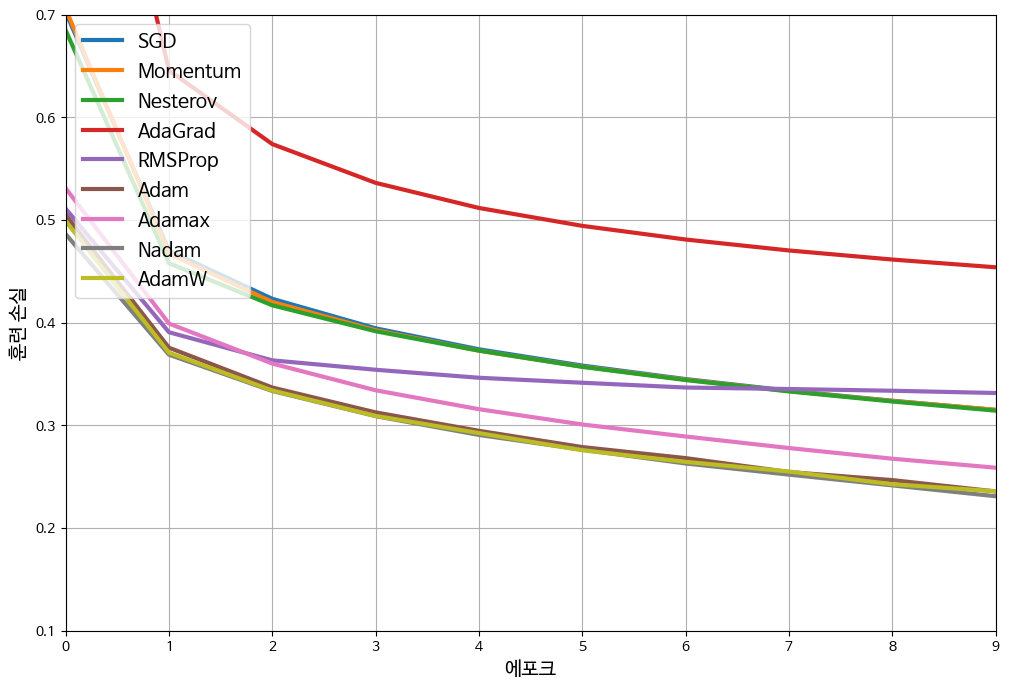

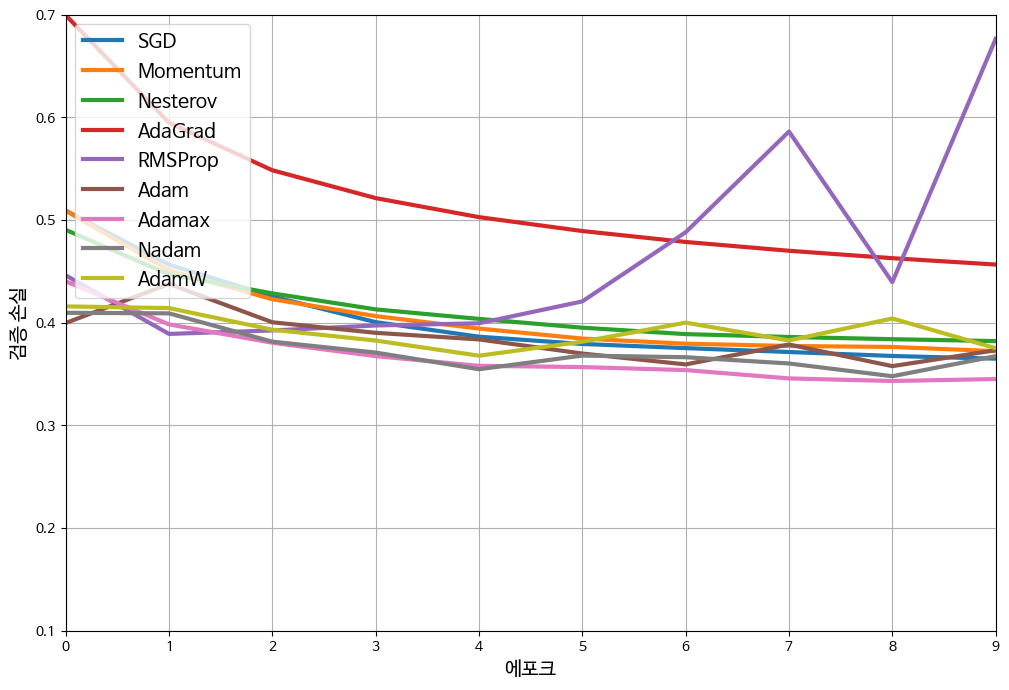

In [34]:
for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("에포크")
    plt.ylabel({"loss": "훈련 손실", "val_loss": "검증 손실"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

## 학습률 스케줄링 
> 큰 학습률로 시작하여 속도가 느려직 때 학습률을 낮춰 최적의 고정 학습률 보다 좋은 솔루션을 발견하는 전략
- 적절하게 학습률을 잡는 것이 중요함 
   - 학습률이 너무 큼 : 훈련이 발산 
   - 학습률이 너무 작음 : 최적점 수렴에 시간이 많이 소요

### 거듭제곱 기반 스케줄링 
- 처음엔 빠르게 감소하다 점점 느리게 감소 
- $\eta_0$ 와 $s$, 그리고 $c$도 튜닝이 필요함 
- 옵티마이저의 `decay` 매개변수는 deprecated
  - `decay` 매개변수를 가진 구형 옵티마이저는 `tf.keras.optimizers.legacy` 있긴 하지만 `tf.keras.optimizers.schedules` 추천

In [ ]:
# DEPRECATED : 교재에 있던 예시
#ptimizer = tf.keras.optimizers.legacy.SGD(learning_rate=0.01, decay=1e-4)

# RECOMMENDED:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

- `InverseTimeDecay` 스케줄러
  - `learning_rate = initial_learning_rate / (1 + decay_rate * step / decay_step)
  -  `staircase = True` :  `step / decay_steps`를 `floor(step / decay_step)`

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6824 - loss: 0.9670 - val_accuracy: 0.8266 - val_loss: 0.4947
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8291 - loss: 0.4901 - val_accuracy: 0.8372 - val_loss: 0.4484
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8475 - loss: 0.4363 - val_accuracy: 0.8456 - val_loss: 0.4248
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8568 - loss: 0.4075 - val_accuracy: 0.8482 - val_loss: 0.4137
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8634 - loss: 0.3877 - val_accuracy: 0.8520 - val_loss: 0.4015
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8691 - loss: 0.3727 - val_accuracy: 0.8540 - val_loss: 0.3926
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8724 - loss: 0.3611 - val_accuracy: 0.8578 - val_loss: 0.3860
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8757 - loss: 0.3514 - 

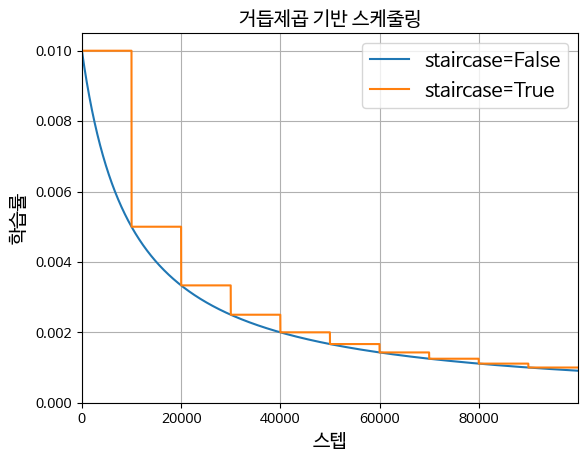

In [37]:
history_power_scheduling = build_and_train_model(optimizer) 

initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

steps = np.arange(100_000)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("스텝")
plt.ylabel("학습률")
plt.title("거듭제곱 기반 스케줄링", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### 지수 기반 스케쥴링 
- 학습률이 갈수록 천천히 감소하면서 $s$번 스텝마다 계속 10배씩 감소 
- learning_rate = initial_learning_rate * decay_rate ** (step / decay_steps)

In [38]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6834 - loss: 0.9345 - val_accuracy: 0.8190 - val_loss: 0.5031
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8271 - loss: 0.4861 - val_accuracy: 0.8368 - val_loss: 0.4537
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8445 - loss: 0.4351 - val_accuracy: 0.8446 - val_loss: 0.4285
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8543 - loss: 0.4078 - val_accuracy: 0.8522 - val_loss: 0.4131
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8607 - loss: 0.3900 - val_accuracy: 0.8576 - val_loss: 0.4027
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8642 - loss: 0.3773 - val_accuracy: 0.8602 - val_loss: 0.3935
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8683 - loss: 0.3675 - val_accuracy: 0.8628 - val_loss: 0.3875
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8703 - loss: 0.3600 - 

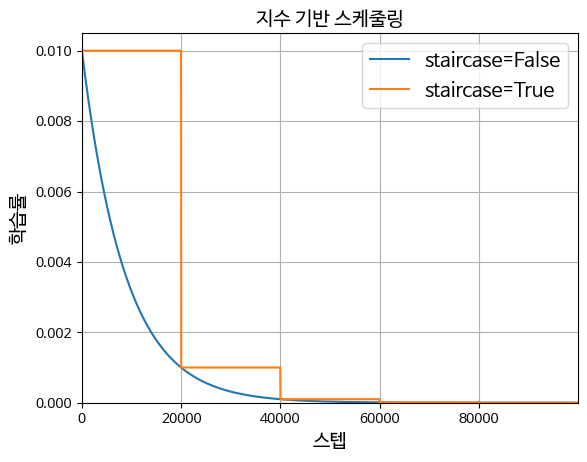

In [39]:
history_exponential_scheduling = build_and_train_model(optimizer)

initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("스텝")
plt.ylabel("학습률")
plt.title("지수 기반 스케줄링", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

- 케라스는 사용자 정의 스케줄링 함수를 위해 `LearningRateScheduler` 콜백 클래스 제공
- 지수 기반 감쇠를 구현하는 방법
  - 스텝이 아니라 에포크마다 학습률이 변경

In [40]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

tf.random.set_seed(42)
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

n_epochs = 20

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6888 - loss: 0.9380 - val_accuracy: 0.8226 - val_loss: 0.4989 - learning_rate: 0.0100
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8299 - loss: 0.4871 - val_accuracy: 0.8348 - val_loss: 0.4549 - learning_rate: 0.0089
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8485 - loss: 0.4350 - val_accuracy: 0.8412 - val_loss: 0.4344 - learning_rate: 0.0079
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8581 - loss: 0.4053 - val_accuracy: 0.8498 - val_loss: 0.4168 - learning_rate: 0.0071
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8653 - loss: 0.3844 - val_accuracy: 0.8520 - val_loss: 0.4052 - learning_rate: 0.0063
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8701 - loss: 0.3691 - val_accuracy: 0.8552 - val_loss: 0.3949 - learning_rate: 0.0056
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8743 - l

In [41]:
def exponential_decay_fn(epoch, lr):
    return lr * 0.1 ** (1 / 20)

K = tf.keras.backend

class ExponentialDecay(tf.keras.callbacks.Callback):
    def __init__(self, n_steps=40_000):
        super().__init__()
        self.n_steps = n_steps

    def on_batch_begin(self, batch, logs=None):
        lr = K.get_value(self.model.optimizer.learning_rate)
        new_learning_rate = lr * 0.1 ** (1 / self.n_steps)
        K.set_value(self.model.optimizer.learning_rate, new_learning_rate)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = K.get_value(self.model.optimizer.learning_rate)

### 구간별 고정 스케쥴링 
- 일정 횟수의 에포크 동안 일정한 학습률 사용
- 다음 에포크 동안은 작은 학습률을 사용 
- 적절한 학습률을 사용하기 위해서는 테스트가 필요



In [ ]:
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[50_000, 80_000],
    values=[0.01, 0.005, 0.001]
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6807 - loss: 0.9495 - val_accuracy: 0.8192 - val_loss: 0.5055
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8260 - loss: 0.4972 - val_accuracy: 0.8306 - val_loss: 0.4613
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8452 - loss: 0.4407 - val_accuracy: 0.8378 - val_loss: 0.4479
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8556 - loss: 0.4085 - val_accuracy: 0.8442 - val_loss: 0.4256
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8629 - loss: 0.3855 - val_accuracy: 0.8458 - val_loss: 0.4149
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8680 - loss: 0.3683 - val_accuracy: 0.8478 - val_loss: 0.4094
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8735 - loss: 0.3539 - val_accuracy: 0.8490 - val_loss: 0.4062
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8766 - loss: 0.3419 - 

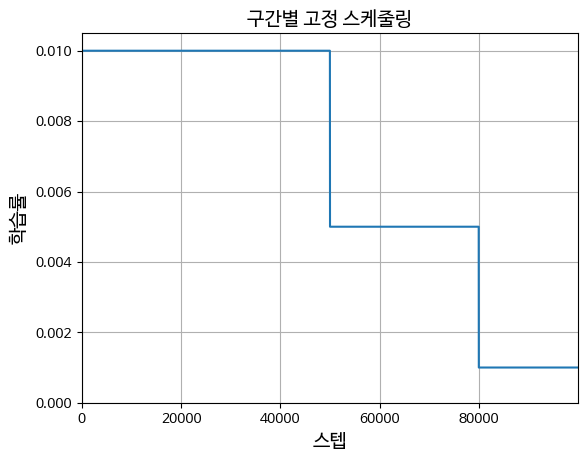

In [43]:
history_piecewise_scheduling = build_and_train_model(optimizer)  

boundaries = [50_000, 80_000]
values = [0.01, 0.005, 0.001]

steps = np.arange(100_000)

lrs = np.full(len(steps), values[0])
for boundary, value in zip(boundaries, values[1:]):
    lrs[boundary:] = value

plt.plot(steps, lrs, "-")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("스텝")
plt.ylabel("학습률")
plt.title("구간별 고정 스케줄링", fontsize=14)
plt.grid(True)
plt.show()

- 구간별 고정 스케줄 수동 구현 

In [44]:
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

### 성능 기반 스케쥴링 
- N 스텝마다 검증 오차를 측정 후 오차가 줄어들지않으면 $\lambda$ 배 만큼 학습률을 감소 시킴 

In [45]:
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [46]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6723 - loss: 0.9799 - val_accuracy: 0.8172 - val_loss: 0.4961 - learning_rate: 0.0100
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8263 - loss: 0.4950 - val_accuracy: 0.8290 - val_loss: 0.4581 - learning_rate: 0.0100
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8459 - loss: 0.4407 - val_accuracy: 0.8314 - val_loss: 0.4423 - learning_rate: 0.0100
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8553 - loss: 0.4088 - val_accuracy: 0.8364 - val_loss: 0.4277 - learning_rate: 0.0100
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8627 - loss: 0.3857 - val_accuracy: 0.8490 - val_loss: 0.4047 - learning_rate: 0.0100
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8685 - loss: 0.3671 - val_accuracy: 0.8542 - val_loss: 0.3920 - learning_rate: 0.0100
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8746 - l

In [47]:
plt.plot(history.epoch, history.history["lr"], "bo-")
plt.xlabel("에포크")
plt.ylabel("학습률", color='b')
plt.tick_params('y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel('검증 손실', color='r')
ax2.tick_params('y', colors='r')

plt.title("평탄 지역에서 LR 감소하기", fontsize=14)
plt.show()

KeyError: 'lr'

### 1사이클 스케쥴링 
- 1사이클은 훈련 절반 동안 초기 학습률 $\eta_0$를 선형적으로 $\eta_n$.까지 증가
- 남은 절반 동안 선형적으로 다시 $\eta_0$ 까지 줄임 
- 마지막 몇 번의 에포크 동안에는 소수점 몇 째 자리까지 줄임 

- `슈퍼 컨버전스`
   - 처음에 높은 모멘텀으로 시작해 훈련에서 처음 절반 동안 모멘텀을 낮춤 
   - 나머지 절반동안은 최댓값으로 다시 되돌림
   - 마지막 몇 에포크는 최댓값으로 진행 함 

In [ ]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_epoch_begin(self, epoch, logs=None):
        self.sum_of_epoch_losses = 0

    def on_batch_end(self, batch, logs=None):
        mean_epoch_loss = logs["loss"]  # 지금까지의 평균 손실
        new_sum_of_epoch_losses = mean_epoch_loss * (batch + 1)
        batch_loss = new_sum_of_epoch_losses - self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_epoch_losses
        self.rates.append(K.get_value(self.model.optimizer.learning_rate))
        self.losses.append(batch_loss)
        K.set_value(self.model.optimizer.learning_rate,
                    self.model.optimizer.learning_rate * self.factor)

- `find_learning_rate()` 함수는 `ExponentialLearningRate` 콜백을 사용하여 모델을 훈련하고 학습률과 해당 배치 손실을 반환
- 마지막에는 모델과 해당 옵티마이저를 초기 상태로 복원

In [50]:
def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-4,
                       max_rate=1):
    init_weights = model.get_weights()
    iterations = math.ceil(len(X) / batch_size) * epochs
    factor = (max_rate / min_rate) ** (1 / iterations)
    init_lr = K.get_value(model.optimizer.learning_rate)
    K.set_value(model.optimizer.learning_rate, min_rate)
    exp_lr = ExponentialLearningRate(factor)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        callbacks=[exp_lr])
    K.set_value(model.optimizer.learning_rate, init_lr)
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses

- `plot_lr_vs_loss()` 함수는 학습률과 손실을 플롯
- 1사이클의 최대 학습률로 사용할 최적의 학습률은 곡선의 맨 아래

In [51]:
def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses, "b")
    plt.gca().set_xscale('log')
    max_loss = losses[0] + min(losses)
    plt.hlines(min(losses), min(rates), max(rates), color="k")
    plt.axis([min(rates), max(rates), 0, max_loss])
    plt.xlabel("학습률")
    plt.ylabel("손실")
    plt.grid()

-----

# 4. 규제를 통한 과대 적합 피하기 

## 규제의 필요성 
- 파라미터의 갯수가 많아 질수록 네트워크의 자유도가 높아짐 
- 이 때문에 과대적합이 발생하기 쉬워짐 

## $\ell_1$ 규제와 $\ell_2$규제
- 신경망의 연결 가중치를 제한하기 위한 규제 
- 일반적으로 네트워크의 모든 은닉층에 동일한 활성화 함수 혹은 동일한 전략을 사용하거나 모든 층에 동일한 규제를 적용 하기 때문에 동일한 매개변수 값을 반복하는 경우가 많음 
   - 리팩터링이 필요할 수 있음 

In [54]:
layer = tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

- 계수가 0.1인 ℓ<sub>1</sub> 정규화의 경우 `l1(0.1)`을 사용하거나, 계수가 각각 0.1과 0.01인 ℓ<sub>1</sub> 및 ℓ<sub>2</sub> 정규화의 경우 `l1_l2(0.1, 0.01)`을 사용

In [55]:
tf.random.set_seed(42)  

from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax")
])

- 모델 구현 및 컴파일

In [56]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7037 - loss: 4.1051 - val_accuracy: 0.8244 - val_loss: 1.8652
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8147 - loss: 1.6265 - val_accuracy: 0.8232 - val_loss: 1.1208


## 드롭 아웃 
> 매 훈련 시스템에서 각 뉴런은 임시적으로 드롭아웃될 확률 $p$를 가짐 
> 즉, 훈현 스텝에서 완전히 무시되거나 되지 않을 수 있음 

- 하이퍼파라미터 $p$ : 드롭 아웃 비율 
   - 10% ~ 50% 사이로 결정 
- 드롭 아웃으로 훈련된 뉴런은 이웃한 뉴런에 맞추어 적응하지 않음 
   - 가능한 자기 자신이 유용해져야함
   - 입력 뉴런 몇개에만 의존 할 수 없고 모든 입력 뉴런에 집중 
   - 결과적으로 일반화 성능이 좋아짐 
- 보존 확률 $(1-p)$ 
   - 뉴런이 훈련 할 때보다 n배 많은 입력이 연결됨 
   - 이를 보상하기 위해 뉴런 연결 가중치를 n배 곱함
   - 훈련하는 동안 각 입력의 연결 가중치를 보존 확률로 나눔 
- 모델이 과대적합 되었다면 드롭아웃 비율을 늘림 


In [57]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

- 모델 컴파일 및 훈련

In [58]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6864 - loss: 0.8760 - val_accuracy: 0.8308 - val_loss: 0.4515
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8083 - loss: 0.5247 - val_accuracy: 0.8430 - val_loss: 0.4134
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8246 - loss: 0.4838 - val_accuracy: 0.8542 - val_loss: 0.3813
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8307 - loss: 0.4603 - val_accuracy: 0.8582 - val_loss: 0.3760
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8397 - loss: 0.4399 - val_accuracy: 0.8568 - val_loss: 0.3751
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8448 - loss: 0.4233 - val_accuracy: 0.8680 - val_loss: 0.3547
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8455 - loss: 0.4187 - val_accuracy: 0.8692 - val_loss: 0.3515
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8497 - loss: 0.4097 - 

- 훈련 정확도가 검증 정확도보다 낮은 것처럼 보이는 이유 
  - 드롭아웃이 훈련 중에만 활성화
  - 훈련 휴 훈련 세트에서 모델을 평가하면 검증 정확도 및 테스트 정확도보다 약간 높은 "실제" 훈련 정확도를 얻음

In [59]:
print("훈련 세트 : ", model.evaluate(X_train, y_train))
print("테스트 세트 : ", model.evaluate(X_test, y_test))

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8838 - loss: 0.3098
훈련 세트 :  [0.31212058663368225, 0.8830181956291199]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8647 - loss: 0.3634
테스트 세트 :  [0.3707137107849121, 0.86080002784729]



## 몬테 카를로 드롭아웃
- 드롭아웃 네트워크와 근사 베이즈 추정 사이의 관련성을 정립 
- MC 드롭 아웃 기법 을 통해 모델을 재훈련 하거나 수정하지 않고 성능을 향상 시킴 


In [62]:
tf.random.set_seed(42) 

y_probas = np.stack([model(X_test, training=True)
                     for sample in range(100)])
y_proba = y_probas.mean(axis=0)

model.predict(X_test[:1]).round(3)

print("y_proba[0].round(3) : ", y_proba[0].round(3))

y_std = y_probas.std(axis=0)
print("y_std[0].round(3) : ",y_std[0].round(3))

y_pred = y_proba.argmax(axis=1)
accuracy = (y_pred == y_test).sum() / len(y_test)
print("accuracy : ",accuracy)

class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
y_proba[0].round(3) :  [0.    0.    0.    0.    0.    0.106 0.    0.19  0.    0.703]
y_std[0].round(3) :  [0.    0.    0.    0.001 0.    0.145 0.    0.18  0.001 0.218]
accuracy :  0.8617


- 시퀀셜 모델 -> MCDropout 변경 

In [63]:
Dropout = tf.keras.layers.Dropout
mc_model = tf.keras.Sequential([
    MCDropout(layer.rate) if isinstance(layer, Dropout) else layer
    for layer in model.layers
])
mc_model.set_weights(model.get_weights())

mc_model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_1 (MCDropout)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_2 (MCDropout)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)


## 맥스 - 노름 규제 
- 뉴런에 입력의 연결 자중치 $\textrm{w}$가 $\Vert w \Vert_2 \leq r$ 이 되도록 제한 
   - $r$ : 맥스-노름 하이퍼 파라미터
      - 증가 시, 규제의 양이 증가하여 과대 적합을 줄일 수 있음
   - $\Vert \cdot \Vert_2$ : $\ell_2$ 노름  
   - 불안정한 그레디언트 완화에 도움을 줌 

In [64]:
dense = tf.keras.layers.Dense(
    100, activation="relu", kernel_initializer="he_normal",
    kernel_constraint=tf.keras.constraints.max_norm(1.))

### 모든 은닉층에 맥스-노름 규제 적용 
MaxNormDense = partial(tf.keras.layers.Dense,
                       activation="relu", kernel_initializer="he_normal",
                       kernel_constraint=tf.keras.constraints.max_norm(1.))

tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    MaxNormDense(100),
    MaxNormDense(100),
    tf.keras.layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7425 - loss: 0.7274 - val_accuracy: 0.8344 - val_loss: 0.4293
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8440 - loss: 0.4261 - val_accuracy: 0.8462 - val_loss: 0.4023
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8595 - loss: 0.3854 - val_accuracy: 0.8326 - val_loss: 0.4174
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8663 - loss: 0.3642 - val_accuracy: 0.8430 - val_loss: 0.4072
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8705 - loss: 0.3511 - val_accuracy: 0.8552 - val_loss: 0.3766
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8739 - loss: 0.3404 - val_accuracy: 0.8538 - val_loss: 0.3866
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8764 - loss: 0.3313 - val_accuracy: 0.8506 - val_loss: 0.3906
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8782 - loss: 0.3260 - 